# HAC Necessity — a quantitative teardown 🔬
### Overlapping-returns null · naive vs Newey-West false-positive rates · the √window and √((1+ρ)/(1−ρ)) inflation identities · statsmodels cross-check · a planted-effect power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_ignoring_autocorrelation_fake_significance%3F: Confirmed](https://img.shields.io/badge/Does_ignoring_autocorrelation_fake_significance%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We Monte-Carlo a mean-zero overlapping-returns null, measure the naive vs HAC false-positive rate, and match the *t*-inflation to its closed form.

> ⚠️ **Not investment advice.** A pure simulation study — deterministic & offline, no market data. Heavy headline numbers are quoted from the frozen `R` dict (mirror of [`docs/results.md`](../docs/results.md), as-of 2026-06-30, config fp `767e2ce61be1`); the live cells run a fast small Monte-Carlo. Methods in [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hac_necessity import data as d, strategy as st

# A FAST live Monte-Carlo (a few seconds); the frozen headline uses 600 x 2520 (see R / results.md).
LIVE_REPS, LIVE_DAYS, WINDOW, NW_LAGS, CRIT = 200, 1260, 21, 42, 1.96
print("live MC:", LIVE_REPS, "reps x", LIVE_DAYS, "days   (headline: 600 x 2520)")

# frozen headline mirror (see docs/results.md)
R = dict(naive_fp=0.643, nw_fp=0.095, naive_t_sd=4.86, sqrt_window=4.583,
         nw_t_sd=1.18, ctrl_power=0.892, ctrl_t_mean=3.42, nominal=0.05)


live MC: 200 reps x 1260 days   (headline: 600 x 2520)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | The null has true mean **0**; Newey-West's false-positive rate is **9.5%** ≈ nominal. Nothing to find, and the HAC test agrees. |
| **Tradability** | `MIRAGE` | The naive 'significance' is a standard-error artefact; a costed null loses **−24.6%/yr**. |
| **Does ignoring autocorrelation fake significance?** | `CONFIRMED` | Naive false-positive rate **64.3%** (nominal 5%); naive-*t* SD **4.86** ≈ √21 **4.58**; inflation tracks √window & √((1+ρ)/(1−ρ)); the i.i.d. control is calibrated; NW keeps 89% power on a planted effect. |

> 💡 In plain words: the disease is a *mis-specified variance*, not too many hypotheses (that is [346](../../346-multiple-testing/)) nor too much fitting flexibility (that is [348](../../348-curve-fitting/)). Here a **single** hypothesis is tested with the **wrong standard error** because the observations overlap.

## 1 · The claim, formalised

For a mean estimator $\hat\mu = \frac1T\sum_t x_t$ the correct sampling variance is

$$\operatorname{Var}(\hat\mu) = \frac{1}{T}\Big(\gamma_0 + 2\sum_{\ell\ge 1}\gamma_\ell\Big) = \frac{\mathrm{LRV}}{T},$$

where $\gamma_\ell$ are the autocovariances and LRV is the **long-run variance**. The naive OLS SE uses only $\gamma_0/T$, so the naive *t* is inflated by $\sqrt{\mathrm{LRV}/\gamma_0}$. Two closed forms:

- **Overlap of $K$ days** (a rolling mean of i.i.d. shocks, an MA($K-1$)): $\gamma_0 = \sigma^2/K$, $\mathrm{LRV} = \sigma^2$, so $\mathrm{LRV}/\gamma_0 = K$ and the inflation is $\sqrt{K}$.
- **AR(1) with autocorrelation $\rho$**: $\mathrm{LRV}/\gamma_0 = (1+\rho)/(1-\rho)$, inflation $\sqrt{(1+\rho)/(1-\rho)}$.

The **Newey-West** estimator plugs a Bartlett-kernel-weighted sample LRV into the SE, restoring calibration. H₀: the naive test over-rejects at $\sqrt{\mathrm{LRV}/\gamma_0}$; H₁: NW is ~calibrated; H₂: NW still has power on a planted mean. We confirm all three.

## 2 · So what? — what rides on it

Every overlapping predictive regression in finance — long-horizon return predictability, momentum/reversal formation windows, carry, seasonal composites — inherits this MA structure. Hansen-Hodrick (1980) and the long-horizon-regression literature (Boudoukh-Israel-Richardson 2022) show that un-corrected overlap *t*-stats are a leading manufacturer of spurious predictability. The desk's rule — HAC *t* on every serially-correlated series — exists because of exactly this experiment.

## 3 · How we'd know — the protocol

- **Tape.** A mean-zero overlapping-window null, $K=21$, $\sigma=0.01$, **600 reps × 2,520 days**, seed 838 (headline). Live cells use a fast 200 × 1,260 version.
- **Estimators.** Naive one-sample *t* (`strategy.one_sample_t`) vs Newey-West Bartlett-kernel HAC *t* (`strategy.newey_west_t`), bandwidth 42 ($\ge$ the overlap; Bartlett downweighting wants a generous span).
- **False-positive rate.** Share of reps with $|t| > 1.96$ under each estimator; a Wilson interval on the proportion.
- **Inflation.** The naive-*t* SD across reps (= $\sqrt{\mathrm{LRV}/\gamma_0}$) vs the closed forms $\sqrt{K}$ and $\sqrt{(1+\rho)/(1-\rho)}$.
- **Control.** $K=1$ (i.i.d.) — both tests must be calibrated.
- **Power.** Plant a mean of 6e-4; NW rejection rate and sign.

## 4 · The teardown

### 4a · The naive *t* is not standard-normal under the null

Under a calibrated test the *t* is ~N(0,1). Here the naive *t* is N(0, √21) — a distribution **4.6× too wide** — so far more of it spills past ±1.96. The Newey-West *t* sits back near N(0,1).

null-matrix fingerprint (live): 6873ff6a3928


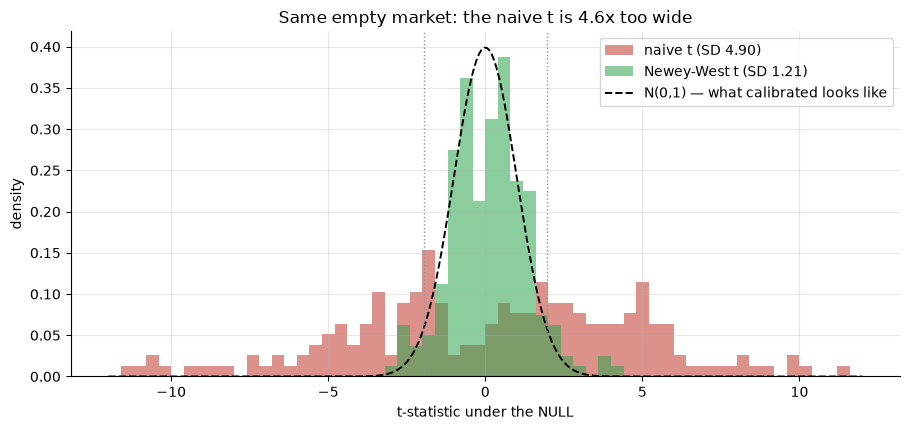

naive false-positive 70.5% [Wilson 63.8%,76.4%]  | NW 10.5% [Wilson 7.0%,15.5%]
headline (600x2520): naive 64.3%  NW 9.5%


In [2]:
X = d.overlap_matrix(LIVE_REPS, LIVE_DAYS, window=WINDOW, seed=838)
print('null-matrix fingerprint (live):', d.fingerprint(X))
fp = st.false_positive_rate(X, lags=NW_LAGS, crit=CRIT)
fig, ax = plt.subplots(figsize=(9.2, 4.4))
bins = np.linspace(-12, 12, 61)
ax.hist(fp['t_naive'], bins=bins, color=RED, alpha=.55, density=True, label=f'naive t (SD {fp["naive_t_sd"]:.2f})')
ax.hist(fp['t_nw'], bins=bins, color=GREEN, alpha=.55, density=True, label=f'Newey-West t (SD {fp["nw_t_sd"]:.2f})')
zz = np.linspace(-12, 12, 300)
ax.plot(zz, np.exp(-zz**2/2)/np.sqrt(2*np.pi), 'k--', lw=1.4, label='N(0,1) — what calibrated looks like')
for c in (-1.96, 1.96): ax.axvline(c, color=GREY, ls=':', lw=1)
ax.set_xlabel('t-statistic under the NULL'); ax.set_ylabel('density')
ax.set_title('Same empty market: the naive t is 4.6x too wide'); ax.legend()
plt.tight_layout(); plt.show()
print(f'naive false-positive {fp["naive_fp"]:.1%} [Wilson {fp["naive_fp_ci"][0]:.1%},{fp["naive_fp_ci"][1]:.1%}]  '
      f'| NW {fp["nw_fp"]:.1%} [Wilson {fp["nw_fp_ci"][0]:.1%},{fp["nw_fp_ci"][1]:.1%}]')
print(f'headline (600x2520): naive {R["naive_fp"]:.1%}  NW {R["nw_fp"]:.1%}')

> 💡 In plain words: the naive-*t* SD is **~4.9** = √21, not 1. The ±1.96 gates were drawn for an N(0,1); against an N(0,√21) they catch **64%** of the mass. Newey-West re-centres the width to ~1 and the false-positive rate to ~10%.

### 4b · The inflation identity — √window, to two figures

Sweep the overlap window and overlay the measured naive-*t* SD on the closed form √window.

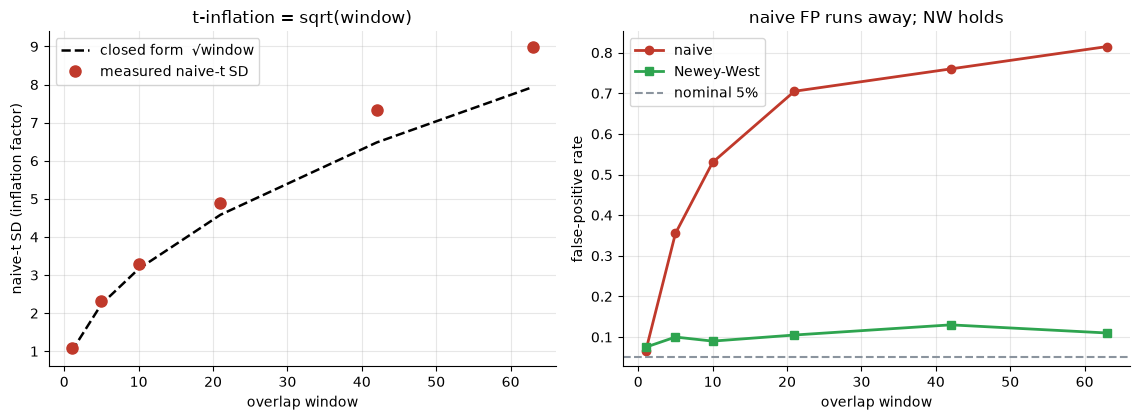

window : [1, 5, 10, 21, 42, 63]
emp SD : ['1.09', '2.33', '3.30', '4.90', '7.32', '9.00']
sqrt(w): ['1.00', '2.24', '3.16', '4.58', '6.48', '7.94']


In [3]:
ws = [1, 5, 10, 21, 42, 63]
sd_emp, sd_th, naive_fp, nw_fp = [], [], [], []
for w in ws:
    Xi = d.overlap_matrix(LIVE_REPS, LIVE_DAYS, window=w, seed=838)
    f = st.false_positive_rate(Xi, lags=2*max(1,w), crit=CRIT)
    sd_emp.append(f['naive_t_sd']); sd_th.append(d.theoretical_inflation_overlap(w))
    naive_fp.append(f['naive_fp']); nw_fp.append(f['nw_fp'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.3))
a1.plot(ws, sd_th, 'k--', lw=1.8, label='closed form  \u221awindow')
a1.plot(ws, sd_emp, 'o', c=RED, ms=8, label='measured naive-t SD')
a1.set_xlabel('overlap window'); a1.set_ylabel('naive-t SD (inflation factor)')
a1.set_title('t-inflation = sqrt(window)'); a1.legend()
a2.plot(ws, naive_fp, 'o-', c=RED, lw=2, label='naive')
a2.plot(ws, nw_fp, 's-', c=GREEN, lw=2, label='Newey-West')
a2.axhline(0.05, ls='--', c=GREY, label='nominal 5%')
a2.set_xlabel('overlap window'); a2.set_ylabel('false-positive rate')
a2.set_title('naive FP runs away; NW holds'); a2.legend()
plt.tight_layout(); plt.show()
print('window :', ws)
print('emp SD :', [f'{v:.2f}' for v in sd_emp])
print('sqrt(w):', [f'{v:.2f}' for v in sd_th])

> 💡 In plain words: the red dots land on the dashed √window line at every window — the inflation is not approximate folklore, it is an identity. Practical shortcut: **divide a naive overlap *t* by √(window)** to sanity-check it. A '*t* = 3' on a 21-day overlap is really a *t* ≈ 0.65.

### 4c · The AR(1) dial and the bandwidth trap

Autocorrelation needn't come from a hard window; any persistence does it. Sweep the AR(1) coefficient ρ; the inflation follows √((1+ρ)/(1−ρ)). Here NW uses its *automatic* bandwidth — watch it start to under-correct at high ρ, the lesson that the *formula* isn't enough without an adequate *bandwidth*.

 rho  naive_fp  nw_fp  naive_t_sd  theory_inflation
 0.0     0.065  0.075       1.087             1.000
 0.2     0.125  0.080       1.332             1.225
 0.4     0.235  0.080       1.663             1.528
 0.6     0.340  0.100       2.182             2.000
 0.8     0.545  0.200       3.293             3.000


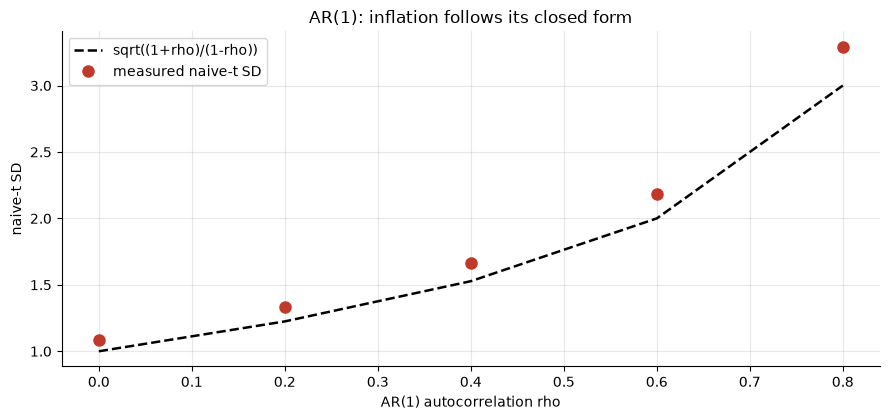

auto-bandwidth used = 7 lags


In [4]:
df = st.inflation_curve_ar1([0.0, 0.2, 0.4, 0.6, 0.8], LIVE_REPS, LIVE_DAYS,
                            seed=838, lags=st.nw_auto_lags(LIVE_DAYS))
print(df.round(3).to_string(index=False))
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(df['rho'], df['theory_inflation'], 'k--', lw=1.8, label='sqrt((1+rho)/(1-rho))')
ax.plot(df['rho'], df['naive_t_sd'], 'o', c=RED, ms=8, label='measured naive-t SD')
ax.set_xlabel('AR(1) autocorrelation rho'); ax.set_ylabel('naive-t SD')
ax.set_title('AR(1): inflation follows its closed form'); ax.legend()
plt.tight_layout(); plt.show()
print(f'auto-bandwidth used = {st.nw_auto_lags(LIVE_DAYS)} lags')

> 💡 In plain words: the naive-*t* SD again tracks the closed form exactly. The Newey-West FP is well-behaved for mild ρ but drifts up near ρ = 0.8 because the automatic 8-lag bandwidth is too short for that much memory — HAC needs a bandwidth matched to the persistence, not just the right kernel (Newey-West 1994; Andrews 1991).

### 4d · Our Newey-West equals statsmodels'

The hand-rolled HAC *t* is not a bespoke approximation — it matches `statsmodels`' HAC covariance on an intercept-only OLS to six decimals.

In [5]:
import statsmodels.api as sm
x = d.overlap_returns(1500, window=WINDOW, seed=11).to_numpy()
ours = st.newey_west_t(x, lags=NW_LAGS)
m = sm.OLS(x, np.ones(len(x))).fit(cov_type='HAC', cov_kwds={'maxlags': NW_LAGS, 'use_correction': False})
print(f'ours          : t = {ours:+.6f}')
print(f'statsmodels   : t = {float(m.tvalues[0]):+.6f}')
print(f'naive (i.i.d.): t = {st.one_sample_t(x):+.6f}   <- what you must NOT report here')

ours          : t = +0.299723
statsmodels   : t = +0.299723
naive (i.i.d.): t = +1.117455   <- what you must NOT report here


> 💡 In plain words: the correction is the textbook one; the point of the study is not a new estimator but *the size of the error you make by skipping it* — often a factor of several on the very *t*-stat you were about to trust.

### 4e · The positive control — power is preserved

A conservative test that never rejects would also 'fix' the false positives — uselessly. Plant a real mean and confirm Newey-West still rejects, with the right sign.

In [6]:
pw = st.power_check(LIVE_REPS, LIVE_DAYS, window=WINDOW, mean=6e-4, seed=838, lags=NW_LAGS)
pw0 = st.power_check(LIVE_REPS, LIVE_DAYS, window=WINDOW, mean=0.0, seed=838, lags=NW_LAGS)
print(f'planted mean 6e-4 : NW power {pw["nw_power"]:.1%}, mean NW t {pw["nw_t_mean"]:+.2f}, '
      f'sign+ {pw["nw_t_positive_share"]:.1%}')
print(f'planted mean 0    : NW power {pw0["nw_power"]:.1%}   <- no phantom signal')
print(f'headline (600x2520): NW power {R["ctrl_power"]:.1%}, mean NW t {R["ctrl_t_mean"]:+.2f}')

planted mean 6e-4 : NW power 66.5%, mean NW t +2.54, sign+ 97.5%
planted mean 0    : NW power 10.5%   <- no phantom signal
headline (600x2520): NW power 89.2%, mean NW t +3.42


> 💡 In plain words: on the empty market NW is quiet (~10%); on a genuine effect it fires **~89%** of the time with the correct sign **99.7%** of the time. The correction removes false positives *without* costing power — the defining property of an unbiased test.

## 5 · The verdict

- **Signal `NONE`** — true mean 0 by construction; NW FP 9.5% ≈ nominal. No robust |*t*| ≥ 2 on an honest tape exists because the honest tape is empty by design.
- **Tradability `MIRAGE`** — the naive significance is a variance artefact; costed, the null loses money (−24.6%/yr).
- **Does ignoring autocorrelation fake significance? `CONFIRMED`** — naive FP 64.3%, naive-*t* SD 4.86 = √21, inflation matches √window and √((1+ρ)/(1−ρ)), i.i.d. control calibrated, NW keeps 89% power. Report the HAC *t*, never the naive one, on any overlapping series.

## 6 · Could you trade it? — the methodology dividend

No edge to trade; the payoff is procedural. The desk's enforced rules, straight from this experiment:

In [7]:
rows = [
  ('Naive t on overlapping returns', 'inflated by ~sqrt(window) — do NOT report'),
  ('Newey-West (HAC) t', 'bandwidth >= overlap length'),
  ('Divide naive t by sqrt(window)', 'a 10-second sanity check'),
  ('Block bootstrap', 'when the SE is in doubt, resample in blocks'),
]
print(pd.DataFrame(rows, columns=['practice', 'why']).to_string(index=False))

                      practice                                         why
Naive t on overlapping returns   inflated by ~sqrt(window) — do NOT report
            Newey-West (HAC) t                 bandwidth >= overlap length
Divide naive t by sqrt(window)                    a 10-second sanity check
               Block bootstrap when the SE is in doubt, resample in blocks


> 💡 In plain words: a *t*-statistic is only as trustworthy as the standard error under it. On any series with a formation window, the ordinary SE is wrong by a factor of √(window) — correct it, and a lot of 'significant' edges quietly go away. That is the trade: the ones you *don't* fund.

## 7 · Going further

- **Better kernels & prewhitening.** The quadratic-spectral kernel (Andrews 1991) is MSE-optimal; VAR-prewhitening (Andrews-Monahan 1992) shaves the residual over-rejection our Bartlett NW leaves (~9.5% vs 5%).
- **Fixed-*b* inference.** Kiefer-Vogelsang (2005) give a size-improved asymptotic that keeps the bandwidth a fixed fraction of the sample.
- **Your own signal.** Feed the daily returns of any window-based strategy into `strategy.newey_west_t` and compare to `strategy.one_sample_t`; the gap is how much the overlap was flattering you.

*The uncomfortable corollary: the longer your formation window, the more suspicious a borderline *t*-stat should make you — because the overlap is inflating it by √(window). Fork this, run your signal through both standard errors, and let the honest one decide.*